
# Task 3 — Proposed Model Improvement V2
## putEMG | Subject-independent development only

This notebook is a **new experiment notebook**. It does not overwrite the earlier Task-2/Task-3 notebooks.

### Why this notebook exists
The earlier MI-GraphSAGE / improved GraphSAGE remained below the Task-2 MLP baseline. This notebook tests whether the gap comes from loss of electrode identity, weak graph construction, or loss of strong flat-feature information.

### Controlled candidates
- **V0 — Current Final GraphSAGE:** loaded from previous Task-3 results; **not retrained**.
- **V1 — GraphSAGE + Electrode Identity Embedding:** isolates whether explicit electrode identity helps.
- **V2 — Multi-feature MI + Weighted GATv2 + Electrode Embedding + Residuals:** uses all seven EMG metrics to estimate channel relationships and lets MI strength influence attention.
- **V3 — Hybrid MLP + V2 GNN:** preserves the strong flat 168-feature representation while adding graph information.

### Experimental rule
Model selection uses only the original Task-2 **31 training subjects + 6 validation subjects**.  
The **7 held-out test subjects are not evaluated in this notebook**.

After screening, optional 5-fold grouped CV can be enabled for the **single best new candidate only**.


In [1]:

# Cell 1 — Imports, reproducibility, paths, and experiment switches

import gc
import json
import math
import random
import re
import subprocess
import sys
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

try:
    import torch_geometric  # noqa: F401
except ImportError:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "torch-geometric"],
        check=False,
    )

import numpy as np
import pandas as pd
from IPython.display import display

from scipy.stats import wilcoxon

from sklearn.feature_selection import VarianceThreshold, mutual_info_regression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder, RobustScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGLoader
from torch_geometric.nn import (
    SAGEConv,
    GATv2Conv,
    global_mean_pool,
    global_max_pool,
)

RANDOM_STATE = 42
N_CHANNELS = 24
METRICS_7 = ["MAV", "RMS", "STD", "VAR", "WL", "ZC", "SSC"]
N_METRICS = len(METRICS_7)
N_CLASSES = 8

# Quick development screening is ON.
RUN_V1 = True
RUN_V2 = True
RUN_V3 = True

# Keep this False first. Turn it on only AFTER the screening table is complete.
RUN_GROUPED_CV_FOR_BEST = True

# Never touch the held-out test in this notebook.
ALLOW_HELD_OUT_TEST = False
assert ALLOW_HELD_OUT_TEST is False

# Multi-feature MI graph estimation uses a subject-balanced training-only sample
# so graph construction is practical even when the feature parquet is very large.
MI_MAX_SAMPLES = 20000

OUTPUT_FOLDER = Path("/kaggle/working/task3_v2_results")
MODEL_FOLDER = OUTPUT_FOLDER / "models"
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)
MODEL_FOLDER.mkdir(parents=True, exist_ok=True)

SCREENING_PATH = OUTPUT_FOLDER / "v2_screening_results.csv"
BEST_CONFIG_PATH = OUTPUT_FOLDER / "v2_best_candidate.json"
CV_PATH = OUTPUT_FOLDER / "v2_best_candidate_cv.csv"

device = "cuda" if torch.cuda.is_available() else "cpu"

def set_all_seeds(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_all_seeds()

print("Device:", device)
print("Output:", OUTPUT_FOLDER)
print("Grouped CV enabled:", RUN_GROUPED_CV_FOR_BEST)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.2 MB/s eta 0:00:00
Device: cuda
Output: /kaggle/working/task3_v2_results
Grouped CV enabled: True


In [2]:
# Cell 2 — Safe artifact discovery

def find_files(filename):
    roots = [Path("/kaggle/working"), Path("/kaggle/input")]
    hits = []

    for root in roots:
        if not root.exists():
            continue

        direct = root / filename
        if direct.exists():
            hits.append(direct.resolve())

        if root.name == "input":
            hits.extend(
                p.resolve()
                for p in root.rglob(filename)
            )

    return sorted(
        set(hits),
        key=lambda p: str(p)
    )


def find_unique(filename, required=True):
    hits = find_files(filename)

    if not hits:
        if required:
            raise FileNotFoundError(
                f"Could not find {filename!r}."
            )
        return None

    if len(hits) > 1:
        raise RuntimeError(
            f"Multiple files named {filename!r} were found."
        )

    return hits[0]


# ============================================================
# FEATURE PARQUET
# ============================================================

parquet_hits = []

for root in [
    Path("/kaggle/input"),
    Path("/kaggle/working")
]:
    if root.exists():

        parquet_hits.extend(
            root.rglob(
                "putemg_window_feature_dataset_filtered_unthresholded*.parquet"
            )
        )


parquet_hits = sorted(
    set(
        p.resolve()
        for p in parquet_hits
    ),
    key=lambda p: str(p)
)


if len(parquet_hits) != 1:
    raise RuntimeError(
        "Expected exactly one filtered/unthresholded "
        "putEMG feature parquet."
    )


FEATURE_PATH = parquet_hits[0]


# ============================================================
# MATCH split_info.json
# ============================================================

split_candidates = []


for p in find_files(
    "split_info.json"
):

    try:

        info = json.load(
            open(p, "r")
        )

        recorded = {
            Path(
                str(
                    info.get(
                        "feature_file",
                        ""
                    )
                )
            ).name,

            Path(
                str(
                    info.get(
                        "feature_path_used",
                        ""
                    )
                )
            ).name,
        }


        if FEATURE_PATH.name in recorded:

            split_candidates.append(
                p
            )

    except Exception:
        pass


if len(split_candidates) != 1:

    raise RuntimeError(
        "Could not uniquely match "
        "the feature parquet to split_info.json."
    )


SPLIT_PATH = split_candidates[0]

TASK2_BASELINE_DIR = (
    SPLIT_PATH.parent
)


BASELINE_RESULTS_PATH = (
    TASK2_BASELINE_DIR
    / "baseline_results.csv"
)

BASELINE_CONFIGS_PATH = (
    TASK2_BASELINE_DIR
    / "baseline_selected_configs.json"
)


assert BASELINE_RESULTS_PATH.exists()
assert BASELINE_CONFIGS_PATH.exists()


# ============================================================
# TASK-3 ARTIFACT SELECTION
# ============================================================

def choose_task3_artifact(
    filename,
    required=True
):

    hits = find_files(
        filename
    )


    if not hits:

        if required:

            raise FileNotFoundError(
                f"Could not find required "
                f"Task-3 artifact: {filename}"
            )

        return None


    # Ignore duplicated resume-artifact copies
    normal_hits = [

        p for p in hits

        if "task3_resume_artifacts"
        not in str(p)
    ]


    if normal_hits:

        hits = normal_hits


    # First choice:
    # direct output of task-3-improvement-2-0
    preferred = [

        p for p in hits

        if (
            "task-3-improvement-2-0"
            in str(p)
            and
            "task3_results"
            in str(p)
        )
    ]


    if preferred:

        return preferred[0]


    # Second choice:
    # dedicated task3-results dataset
    dedicated = [

        p for p in hits

        if "/task3-results/"
        in str(p)
    ]


    if dedicated:

        return dedicated[0]


    if len(hits) == 1:

        return hits[0]


    raise RuntimeError(
        f"Could not uniquely choose "
        f"Task-3 artifact {filename!r}."
    )


FINAL_CONFIG_PATH = (
    choose_task3_artifact(
        "final_config.json",
        required=True
    )
)


ABLATION_PATH = (
    choose_task3_artifact(
        "ablation_screening_results.csv",
        required=False
    )
)


if ABLATION_PATH is None:

    ABLATION_PATH = (
        choose_task3_artifact(
            "ablation_screening_results_recovered.csv",
            required=True
        )
    )


# ============================================================
# TASK-2 PROPOSED OUTPUT
# ============================================================

TASK2_PROPOSED_METRICS_PATH = (
    find_unique(
        "mi_graphsage_validation_metrics.csv",
        required=False
    )
)


TASK2_PROPOSED_CKPT_PATH = (
    find_unique(
        "best_mi_graphsage_checkpoint.pt",
        required=False
    )
)


TASK2_MI_GRAPH_PATH = (
    find_unique(
        "mi_graph.pt",
        required=False
    )
)


print("Artifact loading complete.")

Artifact loading complete.


In [3]:

# Cell 3 — Load dataset, frozen split, and reference results

feature_df = pd.read_parquet(FEATURE_PATH)

with open(SPLIT_PATH, "r") as f:
    split_info = json.load(f)

train_subjects = [int(x) for x in split_info["train_subjects"]]
val_subjects = [int(x) for x in split_info["val_subjects"]]
test_subjects = [int(x) for x in split_info["test_subjects"]]
dev_subjects = sorted(train_subjects + val_subjects)

assert set(train_subjects).isdisjoint(val_subjects)
assert set(train_subjects).isdisjoint(test_subjects)
assert set(val_subjects).isdisjoint(test_subjects)

train_df = feature_df[
    feature_df["subject_id"].isin(train_subjects)
].copy().reset_index(drop=True)

val_df = feature_df[
    feature_df["subject_id"].isin(val_subjects)
].copy().reset_index(drop=True)

dev_df = feature_df[
    feature_df["subject_id"].isin(dev_subjects)
].copy().reset_index(drop=True)

# The test subject IDs are known only because they are part of the saved split.
# No test features or labels are evaluated below.
assert ALLOW_HELD_OUT_TEST is False

baseline_df = pd.read_csv(BASELINE_RESULTS_PATH)
baseline_df["Macro-F1"] = pd.to_numeric(
    baseline_df["Macro-F1"],
    errors="coerce",
)
baseline_df = baseline_df[baseline_df["Macro-F1"].notna()].copy()

best_baseline_row = baseline_df.loc[
    baseline_df["Macro-F1"].idxmax()
]
BEST_BASELINE_NAME = str(best_baseline_row["Model"]).strip()
BEST_BASELINE_VAL_F1 = float(best_baseline_row["Macro-F1"])
BEST_BASELINE_VAL_ACC = float(best_baseline_row["Accuracy"])

with open(BASELINE_CONFIGS_PATH, "r") as f:
    baseline_configs = json.load(f)

with open(FINAL_CONFIG_PATH, "r") as f:
    CURRENT_FINAL_GNN_CONFIG = json.load(f)

ablation_df = pd.read_csv(ABLATION_PATH)
ablation_df["Macro-F1"] = pd.to_numeric(
    ablation_df["Macro-F1"],
    errors="coerce",
)

# Recover the final/current GraphSAGE validation result.
# Prefer the Early stopping stage if it exists because that is the last
# sequential selection stage in the previous Task-3 notebook.
v0_rows = ablation_df[
    ablation_df["Stage"].astype(str).str.lower().eq("early stopping")
].copy()

if v0_rows.empty:
    v0_row = ablation_df.loc[ablation_df["Macro-F1"].idxmax()]
else:
    v0_row = v0_rows.loc[v0_rows["Macro-F1"].idxmax()]

V0_VAL_F1 = float(v0_row["Macro-F1"])
V0_VAL_ACC = float(v0_row["Accuracy"])

task2_proposed_reference = None
if TASK2_PROPOSED_METRICS_PATH is not None:
    tmp = pd.read_csv(TASK2_PROPOSED_METRICS_PATH)
    if len(tmp):
        task2_proposed_reference = tmp.iloc[0].to_dict()

print(f"Rows: {len(feature_df):,}")
print(
    f"Subjects: train={len(train_subjects)}, "
    f"val={len(val_subjects)}, test(frozen)={len(test_subjects)}"
)
print()
print(
    f"Task-2 best baseline: {BEST_BASELINE_NAME} | "
    f"val Macro-F1={BEST_BASELINE_VAL_F1:.4f} | "
    f"Accuracy={BEST_BASELINE_VAL_ACC:.4f}"
)
print(
    f"Current Task-3 Final GraphSAGE (V0): "
    f"val Macro-F1={V0_VAL_F1:.4f} | Accuracy={V0_VAL_ACC:.4f}"
)

if task2_proposed_reference is not None:
    print(
        "Task-2 proposed output loaded:",
        TASK2_PROPOSED_METRICS_PATH,
    )

print("\nCurrent Final-GNN configuration:")
print(json.dumps(CURRENT_FINAL_GNN_CONFIG, indent=2))


Rows: 619,479
Subjects: train=31, val=6, test(frozen)=7

Task-2 best baseline: MLP (PyTorch) | val Macro-F1=0.7398 | Accuracy=0.8464
Current Task-3 Final GraphSAGE (V0): val Macro-F1=0.6550 | Accuracy=0.8121
Task-2 proposed output loaded: /kaggle/input/datasets/tahu663/task-2-proposed-all/mi_graphsage_validation_metrics.csv

Current Final-GNN configuration:
{
  "graph_method": "mi",
  "top_k": 6,
  "edge_weight_mode": "binary",
  "variant": "sage",
  "hidden_dims": [
    64,
    128,
    128
  ],
  "dropout": 0.3,
  "use_batchnorm": true,
  "pooling": "mean_max",
  "optimizer": "adam",
  "scheduler": "none",
  "lr": 0.001,
  "weight_decay": 0.0001,
  "epochs": 100,
  "patience": 10,
  "use_class_weight": false,
  "batch_size": 512
}


In [4]:

# Cell 4 — Exact 168-feature preprocessing from the current pipeline

expected_labels = [int(x) for x in split_info["label_classes"]]

FEAT_PAT_7 = re.compile(
    r"EMG_\d+_(MAV|RMS|STD|VAR|WL|ZC|SSC)",
    re.I,
)

feat_cols_7 = [
    c for c in split_info["feat_cols"]
    if FEAT_PAT_7.fullmatch(c)
]

assert len(feat_cols_7) == 168
assert all(c in feature_df.columns for c in feat_cols_7)

expected_order = [
    f"EMG_{ch}_{metric}"
    for metric in METRICS_7
    for ch in range(1, N_CHANNELS + 1)
]

assert [c.upper() for c in feat_cols_7] == [
    c.upper() for c in expected_order
], "Unexpected feature order."


def preprocess_split(fit_df, transform_df):
    """
    Fit every learned preprocessing step on fit_df only.
    """
    X_fit_raw = fit_df[feat_cols_7].to_numpy(dtype=np.float32)
    X_transform_raw = transform_df[feat_cols_7].to_numpy(dtype=np.float32)

    assert np.isfinite(X_fit_raw).all()
    assert np.isfinite(X_transform_raw).all()

    vt = VarianceThreshold(threshold=0.0)
    X_fit_vt = vt.fit_transform(X_fit_raw)
    X_transform_vt = vt.transform(X_transform_raw)

    assert X_fit_vt.shape[1] == 168, (
        f"Expected 168 retained features, got {X_fit_vt.shape[1]}."
    )

    scaler = RobustScaler()
    X_fit = scaler.fit_transform(X_fit_vt).astype(np.float32)
    X_transform = scaler.transform(X_transform_vt).astype(np.float32)

    le = LabelEncoder()
    y_fit = le.fit_transform(fit_df["label"].to_numpy())

    unseen = set(transform_df["label"]) - set(fit_df["label"])
    assert not unseen, f"Unseen transform labels: {unseen}"

    y_transform = le.transform(transform_df["label"].to_numpy())

    assert [int(x) for x in le.classes_] == expected_labels

    return {
        "X_fit": X_fit,
        "X_transform": X_transform,
        "y_fit": y_fit,
        "y_transform": y_transform,
        "vt": vt,
        "scaler": scaler,
        "le": le,
    }


def to_node_features(X):
    """
    Original feature order is metric-major:
      MAV: EMG1..24, RMS: EMG1..24, ...
    Return one 24 x 7 matrix per window.
    """
    assert X.shape[1] == N_CHANNELS * N_METRICS

    return (
        X.reshape(-1, N_METRICS, N_CHANNELS)
        .transpose(0, 2, 1)
        .astype(np.float32)
    )


def node_to_metric_major_flat(x_nodes):
    """
    x_nodes: [batch, 24, 7]
    Reconstruct the same metric-major 168-feature order used by Task 2.
    """
    return x_nodes.transpose(1, 2).reshape(len(x_nodes), -1)


In [5]:

# Cell 5 — Training-only graph construction
#
# V1 reproduces the previous MAV-only MI topology.
# V2/V3 use a new multi-feature MI graph:
#   - MI estimated separately for all 7 EMG metrics
#   - each metric matrix normalized to [0,1]
#   - matrices averaged
#   - Top-K chosen from the combined score
#   - numerical score is preserved as edge_attr for GATv2

graph_cache = {}


def _subject_key(df):
    return tuple(sorted(int(x) for x in df["subject_id"].unique()))


def subject_balanced_indices(fit_df, max_total, seed=RANDOM_STATE):
    """
    Training-only, approximately subject-balanced sampling for graph estimation.
    This avoids letting subjects with more windows dominate the MI graph.
    """
    n = len(fit_df)
    if n <= max_total:
        return np.arange(n, dtype=int)

    rng = np.random.default_rng(seed)
    subject_values = fit_df["subject_id"].to_numpy()
    subjects = np.unique(subject_values)

    quota = max(1, math.ceil(max_total / len(subjects)))
    chosen = []

    for s in subjects:
        idx = np.flatnonzero(subject_values == s)
        take = min(len(idx), quota)
        chosen.extend(
            rng.choice(idx, size=take, replace=False).tolist()
        )

    chosen = np.asarray(sorted(set(chosen)), dtype=int)

    if len(chosen) > max_total:
        chosen = rng.choice(
            chosen,
            size=max_total,
            replace=False,
        )

    return np.asarray(chosen, dtype=int)


def topk_graph_from_score(score, top_k=6):
    assert score.shape == (N_CHANNELS, N_CHANNELS)
    assert 1 <= int(top_k) < N_CHANNELS

    topology = np.zeros(
        (N_CHANNELS, N_CHANNELS),
        dtype=bool,
    )

    for i in range(N_CHANNELS):
        row = score[i].copy()
        row[i] = -np.inf

        neighbours = np.argsort(row)[-int(top_k):]
        topology[i, neighbours] = True

    topology = np.logical_or(topology, topology.T)
    np.fill_diagonal(topology, False)

    symmetric_score = np.maximum(score, score.T)

    rows, cols = np.nonzero(topology)

    edge_index = torch.tensor(
        np.stack([rows, cols]),
        dtype=torch.long,
    )

    edge_weight = torch.tensor(
        symmetric_score[rows, cols],
        dtype=torch.float32,
    )

    return {
        "score_matrix": symmetric_score.astype(np.float32),
        "topology": topology,
        "edge_index": edge_index,
        "edge_weight": edge_weight,
        "top_k": int(top_k),
        "n_directed_edges": int(edge_index.shape[1]),
        "degree_mean": float(topology.sum(axis=1).mean()),
    }


def build_mav_mi_graph(X_fit_nodes, fit_df, top_k=6):
    """
    Current-project-style MI topology using MAV only.
    Used by V1 so the only main architectural change is electrode identity.
    """
    key = ("mav_mi", _subject_key(fit_df), int(top_k))

    if key in graph_cache:
        return graph_cache[key]

    ch_mav = X_fit_nodes[:, :, 0]

    score = np.zeros(
        (N_CHANNELS, N_CHANNELS),
        dtype=np.float32,
    )

    for target in range(N_CHANNELS):
        score[target] = mutual_info_regression(
            ch_mav,
            ch_mav[:, target],
            random_state=RANDOM_STATE,
        ).astype(np.float32)

    np.fill_diagonal(score, 0.0)

    score = np.nan_to_num(
        score,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    # Normalize only to make stored edge scores easy to interpret.
    max_score = float(score.max())
    if max_score > 0:
        score = score / max_score

    out = topk_graph_from_score(score, top_k)
    out["method"] = "MAV-only MI"
    out["mi_sample_size"] = len(X_fit_nodes)

    graph_cache[key] = out
    return out


def build_multifeature_mi_graph(
    X_fit_nodes,
    fit_df,
    top_k=6,
    max_samples=MI_MAX_SAMPLES,
):
    """
    New V2/V3 graph.

    Uses all seven node metrics while fitting the graph from TRAINING subjects only.
    """
    key = (
        "multi_feature_mi",
        _subject_key(fit_df),
        int(top_k),
        int(max_samples),
    )

    if key in graph_cache:
        return graph_cache[key]

    idx = subject_balanced_indices(
        fit_df,
        max_total=int(max_samples),
        seed=RANDOM_STATE,
    )

    X_sample = X_fit_nodes[idx]

    metric_matrices = []

    t0 = time.time()

    for metric_idx, metric_name in enumerate(METRICS_7):
        Xm = X_sample[:, :, metric_idx]

        M = np.zeros(
            (N_CHANNELS, N_CHANNELS),
            dtype=np.float32,
        )

        for target in range(N_CHANNELS):
            M[target] = mutual_info_regression(
                Xm,
                Xm[:, target],
                random_state=RANDOM_STATE + metric_idx,
            ).astype(np.float32)

        np.fill_diagonal(M, 0.0)

        M = np.nan_to_num(
            M,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )

        # Equalize the influence of the seven metric-specific MI matrices.
        mmax = float(M.max())
        if mmax > 0:
            M = M / mmax

        metric_matrices.append(M)

        print(
            f"MI metric {metric_idx + 1}/{N_METRICS}: "
            f"{metric_name} complete"
        )

    combined = np.mean(
        np.stack(metric_matrices, axis=0),
        axis=0,
    ).astype(np.float32)

    np.fill_diagonal(combined, 0.0)

    out = topk_graph_from_score(
        combined,
        top_k=top_k,
    )

    out["method"] = "7-metric averaged MI"
    out["mi_sample_size"] = int(len(idx))
    out["graph_build_seconds"] = float(time.time() - t0)
    out["metric_names"] = list(METRICS_7)

    graph_cache[key] = out
    return out


In [6]:

# Cell 6 — Lazy graph dataset and evaluation metrics

class EMGGraphDataset(Dataset):
    def __init__(
        self,
        X_nodes,
        y,
        edge_index,
        edge_weight,
    ):
        self.X_nodes = X_nodes
        self.y = np.asarray(y)
        self.edge_index = edge_index
        self.edge_weight = edge_weight

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return Data(
            x=torch.as_tensor(
                self.X_nodes[idx],
                dtype=torch.float32,
            ),
            edge_index=self.edge_index,
            edge_attr=self.edge_weight.unsqueeze(1),
            y=torch.tensor(
                int(self.y[idx]),
                dtype=torch.long,
            ),
        )


def make_loader(dataset, batch_size=512, shuffle=False):
    return PyGLoader(
        dataset,
        batch_size=int(batch_size),
        shuffle=bool(shuffle),
        num_workers=0,
    )


def full_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    return {
        "Accuracy": float(
            accuracy_score(y_true, y_pred)
        ),
        "Balanced Accuracy": float(
            balanced_accuracy_score(y_true, y_pred)
        ),
        "Macro Precision": float(
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "Macro Recall": float(
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "Macro-F1": float(
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "Weighted-F1": float(
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
        ),
        "MCC": float(
            matthews_corrcoef(
                y_true,
                y_pred,
            )
        ),
    }


def predict_model(model, loader):
    model.eval()

    ys = []
    preds = []
    scores = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            logits = model(
                batch.x,
                batch.edge_index,
                batch.edge_attr.squeeze(1),
                batch.batch,
            )

            ys.append(
                batch.y.detach().cpu().numpy()
            )
            preds.append(
                logits.argmax(dim=1).detach().cpu().numpy()
            )
            scores.append(
                torch.softmax(
                    logits,
                    dim=1,
                ).detach().cpu().numpy()
            )

    return (
        np.concatenate(ys),
        np.concatenate(preds),
        np.concatenate(scores),
    )



## Model V1 — GraphSAGE + electrode identity

The previous GNN only gave each node the seven signal features. V1 adds an 8-dimensional learnable embedding for the fixed electrode identity (`EMG_1 ... EMG_24`) while keeping the previous GraphSAGE-style topology.

This directly tests whether the GNN was losing useful physical sensor identity during permutation-invariant graph pooling.


In [7]:

# Cell 7 — V1: Embedded GraphSAGE

class EmbeddedGraphSAGE(nn.Module):
    def __init__(
        self,
        hidden_dims=(64, 128, 128),
        electrode_embed_dim=8,
        dropout=0.3,
        use_batchnorm=True,
        n_classes=N_CLASSES,
    ):
        super().__init__()

        self.electrode_embedding = nn.Embedding(
            N_CHANNELS,
            electrode_embed_dim,
        )

        dims = [
            N_METRICS + electrode_embed_dim,
            *list(hidden_dims),
        ]

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        for d_in, d_out in zip(
            dims[:-1],
            dims[1:],
        ):
            self.convs.append(
                SAGEConv(d_in, d_out)
            )

            self.norms.append(
                nn.BatchNorm1d(d_out)
                if use_batchnorm
                else nn.Identity()
            )

        last_dim = dims[-1]

        self.fc1 = nn.Linear(
            last_dim * 2,
            128,
        )
        self.fc2 = nn.Linear(
            128,
            n_classes,
        )

        self.dropout = float(dropout)

    def forward(
        self,
        x,
        edge_index,
        edge_weight,
        batch,
    ):
        # Every graph always contains exactly 24 electrodes in fixed order.
        electrode_id = (
            torch.arange(
                x.size(0),
                device=x.device,
            )
            % N_CHANNELS
        )

        emb = self.electrode_embedding(
            electrode_id
        )

        x = torch.cat(
            [x, emb],
            dim=1,
        )

        for conv, norm in zip(
            self.convs,
            self.norms,
        ):
            x = conv(
                x,
                edge_index,
            )
            x = F.relu(
                norm(x)
            )

        graph_x = torch.cat(
            [
                global_mean_pool(
                    x,
                    batch,
                ),
                global_max_pool(
                    x,
                    batch,
                ),
            ],
            dim=1,
        )

        graph_x = F.relu(
            self.fc1(
                graph_x
            )
        )

        graph_x = F.dropout(
            graph_x,
            p=self.dropout,
            training=self.training,
        )

        return self.fc2(
            graph_x
        )



## Model V2 — multi-feature MI + weighted GATv2

V2 changes the graph representation itself:

1. electrode identity embedding is retained;
2. the graph is estimated from all seven EMG metrics, not MAV alone;
3. the numerical MI strength is supplied to `GATv2Conv` as a 1-D edge attribute;
4. residual connections preserve the previous node representation;
5. LayerNorm and small graph-layer dropout are used to reduce unstable/over-smoothed representations.


In [8]:

# Cell 8 — V2: Weighted GATv2 with residual connections

class WeightedGATv2Encoder(nn.Module):
    def __init__(
        self,
        electrode_embed_dim=8,
        graph_dropout=0.15,
    ):
        super().__init__()

        self.electrode_embedding = nn.Embedding(
            N_CHANNELS,
            electrode_embed_dim,
        )

        in_dim = N_METRICS + electrode_embed_dim

        # 32 x 2 heads = 64 output
        self.gat1 = GATv2Conv(
            in_dim,
            32,
            heads=2,
            concat=True,
            dropout=graph_dropout,
            edge_dim=1,
            add_self_loops=True,
        )

        self.res1 = nn.Linear(
            in_dim,
            64,
        )

        self.norm1 = nn.LayerNorm(
            64
        )

        # 32 x 4 heads = 128 output
        self.gat2 = GATv2Conv(
            64,
            32,
            heads=4,
            concat=True,
            dropout=graph_dropout,
            edge_dim=1,
            add_self_loops=True,
        )

        self.res2 = nn.Linear(
            64,
            128,
        )

        self.norm2 = nn.LayerNorm(
            128
        )

        self.graph_dropout = float(
            graph_dropout
        )

    def forward(
        self,
        x,
        edge_index,
        edge_weight,
        batch,
    ):
        electrode_id = (
            torch.arange(
                x.size(0),
                device=x.device,
            )
            % N_CHANNELS
        )

        emb = self.electrode_embedding(
            electrode_id
        )

        h0 = torch.cat(
            [x, emb],
            dim=1,
        )

        edge_attr = edge_weight.unsqueeze(1)

        h1 = self.gat1(
            h0,
            edge_index,
            edge_attr=edge_attr,
        )

        h1 = self.norm1(
            h1 + self.res1(h0)
        )

        h1 = F.relu(h1)

        h1 = F.dropout(
            h1,
            p=self.graph_dropout,
            training=self.training,
        )

        h2 = self.gat2(
            h1,
            edge_index,
            edge_attr=edge_attr,
        )

        h2 = self.norm2(
            h2 + self.res2(h1)
        )

        h2 = F.relu(h2)

        h2 = F.dropout(
            h2,
            p=self.graph_dropout,
            training=self.training,
        )

        pooled = torch.cat(
            [
                global_mean_pool(
                    h2,
                    batch,
                ),
                global_max_pool(
                    h2,
                    batch,
                ),
            ],
            dim=1,
        )

        return pooled


class WeightedGATv2Classifier(nn.Module):
    def __init__(
        self,
        n_classes=N_CLASSES,
        classifier_dropout=0.3,
    ):
        super().__init__()

        self.encoder = WeightedGATv2Encoder()

        self.fc1 = nn.Linear(
            256,
            128,
        )

        self.fc2 = nn.Linear(
            128,
            n_classes,
        )

        self.dropout = float(
            classifier_dropout
        )

    def forward(
        self,
        x,
        edge_index,
        edge_weight,
        batch,
    ):
        pooled = self.encoder(
            x,
            edge_index,
            edge_weight,
            batch,
        )

        h = F.relu(
            self.fc1(
                pooled
            )
        )

        h = F.dropout(
            h,
            p=self.dropout,
            training=self.training,
        )

        return self.fc2(h)



## Model V3 — Hybrid MLP + graph branch

The Task-2 MLP is already strong on the flat 168-feature representation. V3 therefore does **not** force the graph branch to replace it.

- **MLP branch:** preserves electrode-specific flat features.
- **GNN branch:** learns inter-electrode relationships.
- The two representations are concatenated before classification.

If V3 improves over the MLP, the improvement can be attributed to complementary graph information rather than simply replacing the baseline representation.


In [9]:

# Cell 9 — V3: Hybrid flat-feature MLP + weighted GATv2

class HybridMLPGATv2(nn.Module):
    def __init__(
        self,
        n_classes=N_CLASSES,
        dropout=0.3,
    ):
        super().__init__()

        self.gnn_encoder = WeightedGATv2Encoder()

        # First two levels mirror the strong Task-2 MLP feature hierarchy.
        self.flat_branch = nn.Sequential(
            nn.Linear(168, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.graph_projection = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
        )

        self.fusion = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def forward(
        self,
        x,
        edge_index,
        edge_weight,
        batch,
    ):
        graph_repr = self.gnn_encoder(
            x,
            edge_index,
            edge_weight,
            batch,
        )

        graph_repr = self.graph_projection(
            graph_repr
        )

        batch_size = int(
            batch.max().item()
        ) + 1

        # PyG concatenates each 24-node graph in order.
        x_nodes = x.view(
            batch_size,
            N_CHANNELS,
            N_METRICS,
        )

        # Convert channel-major node matrix back to metric-major flat order:
        # [MAV ch1..24, RMS ch1..24, ...]
        x_flat = (
            x_nodes
            .transpose(1, 2)
            .contiguous()
            .view(batch_size, 168)
        )

        flat_repr = self.flat_branch(
            x_flat
        )

        fused = torch.cat(
            [
                flat_repr,
                graph_repr,
            ],
            dim=1,
        )

        return self.fusion(
            fused
        )


In [10]:

# Cell 10 — Candidate training helper
#
# All candidates use the same preprocessing, labels, early-stopping metric,
# optimizer family, and original train/validation subjects.
#
# No full inverse-frequency class weighting is used because the previous
# Task-3 ablation found it harmful.

def build_candidate_model(candidate_name):
    if candidate_name == "V1_EmbeddedGraphSAGE":
        return EmbeddedGraphSAGE(
            hidden_dims=tuple(
                CURRENT_FINAL_GNN_CONFIG.get(
                    "hidden_dims",
                    [64, 128, 128],
                )
            ),
            electrode_embed_dim=8,
            dropout=float(
                CURRENT_FINAL_GNN_CONFIG.get(
                    "dropout",
                    0.3,
                )
            ),
            use_batchnorm=bool(
                CURRENT_FINAL_GNN_CONFIG.get(
                    "use_batchnorm",
                    True,
                )
            ),
        )

    if candidate_name == "V2_WeightedGATv2":
        return WeightedGATv2Classifier()

    if candidate_name == "V3_HybridMLP_GATv2":
        return HybridMLPGATv2()

    raise ValueError(
        f"Unknown candidate: {candidate_name}"
    )


def build_candidate_graph(
    candidate_name,
    X_fit_nodes,
    fit_df,
):
    top_k = int(
        CURRENT_FINAL_GNN_CONFIG.get(
            "top_k",
            6,
        )
    )

    if candidate_name == "V1_EmbeddedGraphSAGE":
        return build_mav_mi_graph(
            X_fit_nodes,
            fit_df,
            top_k=top_k,
        )

    return build_multifeature_mi_graph(
        X_fit_nodes,
        fit_df,
        top_k=top_k,
        max_samples=MI_MAX_SAMPLES,
    )


def train_candidate(
    fit_df,
    validation_df,
    candidate_name,
    seed=RANDOM_STATE,
    verbose=True,
):
    set_all_seeds(seed)

    prep = preprocess_split(
        fit_df,
        validation_df,
    )

    X_fit_nodes = to_node_features(
        prep["X_fit"]
    )
    X_val_nodes = to_node_features(
        prep["X_transform"]
    )

    graph_t0 = time.time()

    graph = build_candidate_graph(
        candidate_name,
        X_fit_nodes,
        fit_df,
    )

    graph_seconds = float(
        time.time() - graph_t0
    )

    train_ds = EMGGraphDataset(
        X_fit_nodes,
        prep["y_fit"],
        graph["edge_index"],
        graph["edge_weight"],
    )

    val_ds = EMGGraphDataset(
        X_val_nodes,
        prep["y_transform"],
        graph["edge_index"],
        graph["edge_weight"],
    )

    batch_size = int(
        CURRENT_FINAL_GNN_CONFIG.get(
            "batch_size",
            512,
        )
    )

    train_loader = make_loader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = make_loader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
    )

    model = build_candidate_model(
        candidate_name
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3,
        weight_decay=1e-4,
    )

    max_epochs = 100
    patience = 10

    best_f1 = -np.inf
    best_epoch = None
    best_state = None
    patience_counter = 0
    history = []

    model_path = (
        MODEL_FOLDER
        / f"{candidate_name}_best.pt"
    )

    t0 = time.time()

    for epoch in range(
        1,
        max_epochs + 1,
    ):
        model.train()

        loss_sum = 0.0

        for batch in train_loader:
            batch = batch.to(device)

            optimizer.zero_grad(
                set_to_none=True
            )

            logits = model(
                batch.x,
                batch.edge_index,
                batch.edge_attr.squeeze(1),
                batch.batch,
            )

            loss = loss_fn(
                logits,
                batch.y,
            )

            if not torch.isfinite(loss):
                raise RuntimeError(
                    f"Non-finite loss in {candidate_name}, epoch {epoch}"
                )

            loss.backward()
            optimizer.step()

            loss_sum += float(
                loss.item()
            )

        y_val, pred_val, score_val = predict_model(
            model,
            val_loader,
        )

        val_f1 = f1_score(
            y_val,
            pred_val,
            average="macro",
            zero_division=0,
        )

        improved = (
            val_f1
            > best_f1 + 1e-8
        )

        if improved:
            best_f1 = float(
                val_f1
            )

            best_epoch = int(
                epoch
            )

            best_state = {
                k: v.detach().cpu().clone()
                for k, v
                in model.state_dict().items()
            }

            patience_counter = 0

            # Save the best checkpoint immediately.
            torch.save(
                {
                    "candidate": candidate_name,
                    "epoch": best_epoch,
                    "best_macro_f1": best_f1,
                    "model_state_dict": best_state,
                    "graph_method": graph["method"],
                    "top_k": graph["top_k"],
                    "seed": int(seed),
                },
                model_path,
            )

        else:
            patience_counter += 1

        history.append(
            {
                "epoch": int(epoch),
                "train_loss": (
                    loss_sum
                    / max(
                        len(train_loader),
                        1,
                    )
                ),
                "val_macro_f1": float(
                    val_f1
                ),
            }
        )

        if verbose and (
            epoch == 1
            or epoch % 5 == 0
            or improved
            or patience_counter >= patience
        ):
            print(
                f"{candidate_name} | "
                f"epoch {epoch:03d} | "
                f"val Macro-F1={val_f1:.4f} | "
                f"best={best_f1:.4f} | "
                f"patience={patience_counter}/{patience}"
            )

        if patience_counter >= patience:
            break

    assert best_state is not None
    assert best_epoch is not None

    model.load_state_dict(
        best_state
    )

    y_val, pred_val, score_val = predict_model(
        model,
        val_loader,
    )

    metrics = full_metrics(
        y_val,
        pred_val,
    )

    metrics.update(
        {
            "Candidate": candidate_name,
            "Best epoch": int(best_epoch),
            "Epochs run": int(len(history)),
            "Train time (s)": float(
                time.time() - t0
            ),
            "Graph build time (s)": graph_seconds,
            "Graph method": graph["method"],
            "Top-K": int(graph["top_k"]),
            "MI sample size": int(
                graph.get(
                    "mi_sample_size",
                    len(fit_df),
                )
            ),
            "Checkpoint": str(model_path),
        }
    )

    artifacts = {
        "prep": prep,
        "graph": graph,
        "history": history,
        "best_state": best_state,
    }

    del train_loader, val_loader, train_ds, val_ds
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics, model, artifacts


In [11]:

# Cell 11 — Screening result persistence
#
# A completed candidate is saved immediately to CSV.
# If you later attach a previous V2 output as a Kaggle input,
# completed candidates can be recovered and skipped.

def find_previous_screening():
    if SCREENING_PATH.exists():
        return SCREENING_PATH

    hits = []
    root = Path("/kaggle/input")

    if root.exists():
        hits = sorted(
            set(
                p.resolve()
                for p in root.rglob(
                    "v2_screening_results.csv"
                )
            ),
            key=lambda p: str(p),
        )

    if len(hits) == 1:
        return hits[0]

    if len(hits) > 1:
        raise RuntimeError(
            "Multiple previous V2 screening files found:\n"
            + "\n".join(str(p) for p in hits)
        )

    return None


previous_screening = find_previous_screening()

if previous_screening is None:
    screening_df = pd.DataFrame()
else:
    screening_df = pd.read_csv(
        previous_screening
    )
    print(
        "Recovered previous V2 screening:",
        previous_screening,
    )


def candidate_already_done(name):
    if screening_df.empty:
        return False

    return name in set(
        screening_df["Candidate"].astype(str)
    )


def append_screening_result(row):
    global screening_df

    new_row = pd.DataFrame([row])

    if screening_df.empty:
        screening_df = new_row
    else:
        screening_df = pd.concat(
            [screening_df, new_row],
            ignore_index=True,
        )

    screening_df = (
        screening_df
        .drop_duplicates(
            subset=["Candidate"],
            keep="last",
        )
        .reset_index(drop=True)
    )

    screening_df.to_csv(
        SCREENING_PATH,
        index=False,
    )

    print(
        "Saved screening progress:",
        SCREENING_PATH,
    )


In [12]:

# Cell 12 — Register V0 reference and run V1

# V0 is reference only. It is not retrained here.
v0_record = {
    "Candidate": "V0_Current_Final_GraphSAGE",
    "Macro-F1": V0_VAL_F1,
    "Accuracy": V0_VAL_ACC,
    "Balanced Accuracy": np.nan,
    "Macro Precision": np.nan,
    "Macro Recall": np.nan,
    "Weighted-F1": np.nan,
    "MCC": np.nan,
    "Best epoch": np.nan,
    "Epochs run": np.nan,
    "Train time (s)": np.nan,
    "Graph build time (s)": np.nan,
    "Graph method": CURRENT_FINAL_GNN_CONFIG.get(
        "graph_method",
        "mi",
    ),
    "Top-K": CURRENT_FINAL_GNN_CONFIG.get(
        "top_k",
        6,
    ),
    "MI sample size": np.nan,
    "Checkpoint": "Previous Task-3 result; not retrained",
}

if not candidate_already_done(
    "V0_Current_Final_GraphSAGE"
):
    append_screening_result(
        v0_record
    )


if RUN_V1 and not candidate_already_done(
    "V1_EmbeddedGraphSAGE"
):
    v1_metrics, v1_model, v1_artifacts = train_candidate(
        train_df,
        val_df,
        "V1_EmbeddedGraphSAGE",
        seed=RANDOM_STATE,
        verbose=True,
    )

    append_screening_result(
        v1_metrics
    )
else:
    print(
        "V1 skipped: disabled or already completed."
    )


Saved screening progress: /kaggle/working/task3_v2_results/v2_screening_results.csv
V1_EmbeddedGraphSAGE | epoch 001 | val Macro-F1=0.6806 | best=0.6806 | patience=0/10
V1_EmbeddedGraphSAGE | epoch 005 | val Macro-F1=0.6100 | best=0.6806 | patience=4/10
V1_EmbeddedGraphSAGE | epoch 007 | val Macro-F1=0.7113 | best=0.7113 | patience=0/10
V1_EmbeddedGraphSAGE | epoch 010 | val Macro-F1=0.6943 | best=0.7113 | patience=3/10
V1_EmbeddedGraphSAGE | epoch 015 | val Macro-F1=0.6632 | best=0.7113 | patience=8/10
V1_EmbeddedGraphSAGE | epoch 017 | val Macro-F1=0.6362 | best=0.7113 | patience=10/10
Saved screening progress: /kaggle/working/task3_v2_results/v2_screening_results.csv


In [13]:

# Cell 13 — Run V2

if RUN_V2 and not candidate_already_done(
    "V2_WeightedGATv2"
):
    v2_metrics, v2_model, v2_artifacts = train_candidate(
        train_df,
        val_df,
        "V2_WeightedGATv2",
        seed=RANDOM_STATE,
        verbose=True,
    )

    append_screening_result(
        v2_metrics
    )
else:
    print(
        "V2 skipped: disabled or already completed."
    )


MI metric 1/7: MAV complete
MI metric 2/7: RMS complete
MI metric 3/7: STD complete
MI metric 4/7: VAR complete
MI metric 5/7: WL complete
MI metric 6/7: ZC complete
MI metric 7/7: SSC complete
V2_WeightedGATv2 | epoch 001 | val Macro-F1=0.7221 | best=0.7221 | patience=0/10
V2_WeightedGATv2 | epoch 002 | val Macro-F1=0.7308 | best=0.7308 | patience=0/10
V2_WeightedGATv2 | epoch 004 | val Macro-F1=0.7323 | best=0.7323 | patience=0/10
V2_WeightedGATv2 | epoch 005 | val Macro-F1=0.7196 | best=0.7323 | patience=1/10
V2_WeightedGATv2 | epoch 010 | val Macro-F1=0.7169 | best=0.7323 | patience=6/10
V2_WeightedGATv2 | epoch 014 | val Macro-F1=0.7113 | best=0.7323 | patience=10/10
Saved screening progress: /kaggle/working/task3_v2_results/v2_screening_results.csv


In [14]:

# Cell 14 — Run V3

if RUN_V3 and not candidate_already_done(
    "V3_HybridMLP_GATv2"
):
    v3_metrics, v3_model, v3_artifacts = train_candidate(
        train_df,
        val_df,
        "V3_HybridMLP_GATv2",
        seed=RANDOM_STATE,
        verbose=True,
    )

    append_screening_result(
        v3_metrics
    )
else:
    print(
        "V3 skipped: disabled or already completed."
    )


V3_HybridMLP_GATv2 | epoch 001 | val Macro-F1=0.7268 | best=0.7268 | patience=0/10
V3_HybridMLP_GATv2 | epoch 002 | val Macro-F1=0.7281 | best=0.7281 | patience=0/10
V3_HybridMLP_GATv2 | epoch 004 | val Macro-F1=0.7296 | best=0.7296 | patience=0/10
V3_HybridMLP_GATv2 | epoch 005 | val Macro-F1=0.7357 | best=0.7357 | patience=0/10
V3_HybridMLP_GATv2 | epoch 010 | val Macro-F1=0.7145 | best=0.7357 | patience=5/10
V3_HybridMLP_GATv2 | epoch 015 | val Macro-F1=0.7030 | best=0.7357 | patience=10/10
Saved screening progress: /kaggle/working/task3_v2_results/v2_screening_results.csv


In [15]:

# Cell 15 — Development comparison and best-candidate selection
#
# The Task-2 MLP baseline row is added for context only; it is not retrained.

screening_df = pd.read_csv(
    SCREENING_PATH
)

baseline_context = pd.DataFrame(
    [
        {
            "Candidate": (
                "Task2_Best_Baseline__"
                + BEST_BASELINE_NAME
            ),
            "Macro-F1": BEST_BASELINE_VAL_F1,
            "Accuracy": BEST_BASELINE_VAL_ACC,
            "Result source": "Task-2 baseline_results.csv",
        }
    ]
)

comparison_cols = [
    "Candidate",
    "Macro-F1",
    "Accuracy",
    "Balanced Accuracy",
    "Best epoch",
    "Train time (s)",
    "Graph method",
    "Top-K",
]

for col in comparison_cols:
    if col not in screening_df.columns:
        screening_df[col] = np.nan

comparison_df = pd.concat(
    [
        baseline_context,
        screening_df,
    ],
    ignore_index=True,
    sort=False,
)

comparison_df["Macro-F1"] = pd.to_numeric(
    comparison_df["Macro-F1"],
    errors="coerce",
)

comparison_df = comparison_df.sort_values(
    "Macro-F1",
    ascending=False,
).reset_index(drop=True)

display(
    comparison_df[
        [
            "Candidate",
            "Macro-F1",
            "Accuracy",
            "Balanced Accuracy",
            "Best epoch",
            "Train time (s)",
            "Graph method",
            "Top-K",
        ]
    ]
)

new_candidates = screening_df[
    screening_df["Candidate"].isin(
        [
            "V1_EmbeddedGraphSAGE",
            "V2_WeightedGATv2",
            "V3_HybridMLP_GATv2",
        ]
    )
].copy()

expected_new = {
    "V1_EmbeddedGraphSAGE",
    "V2_WeightedGATv2",
    "V3_HybridMLP_GATv2",
}

if set(new_candidates["Candidate"]) == expected_new:
    best_new_row = new_candidates.loc[
        pd.to_numeric(
            new_candidates["Macro-F1"],
            errors="coerce",
        ).idxmax()
    ]

    BEST_NEW_CANDIDATE = str(
        best_new_row["Candidate"]
    )

    BEST_NEW_F1 = float(
        best_new_row["Macro-F1"]
    )

    best_summary = {
        "best_new_candidate": BEST_NEW_CANDIDATE,
        "best_new_validation_macro_f1": BEST_NEW_F1,
        "task2_best_baseline": BEST_BASELINE_NAME,
        "task2_best_baseline_validation_macro_f1": BEST_BASELINE_VAL_F1,
        "delta_vs_task2_baseline": (
            BEST_NEW_F1
            - BEST_BASELINE_VAL_F1
        ),
        "current_v0_macro_f1": V0_VAL_F1,
        "delta_vs_current_v0": (
            BEST_NEW_F1
            - V0_VAL_F1
        ),
        "selection_data": "Task-2 original 31-train / 6-validation subjects only",
        "held_out_test_used": False,
    }

    with open(
        BEST_CONFIG_PATH,
        "w",
    ) as f:
        json.dump(
            best_summary,
            f,
            indent=2,
        )

    print()
    print(
        "Best NEW candidate:",
        BEST_NEW_CANDIDATE,
    )

    print(
        f"Validation Macro-F1: "
        f"{BEST_NEW_F1:.4f}"
    )

    print(
        f"Delta vs current Final GraphSAGE: "
        f"{BEST_NEW_F1 - V0_VAL_F1:+.4f}"
    )

    print(
        f"Delta vs Task-2 best baseline: "
        f"{BEST_NEW_F1 - BEST_BASELINE_VAL_F1:+.4f}"
    )

    if BEST_NEW_F1 > BEST_BASELINE_VAL_F1:
        print(
            "Development result: the new candidate is above "
            "the saved Task-2 baseline on the original validation subjects. "
            "Grouped CV is still required before any stronger claim."
        )
    else:
        print(
            "Development result: the new candidate is still below "
            "the Task-2 baseline. Do not touch the held-out test."
        )

else:
    BEST_NEW_CANDIDATE = None

    print(
        "Screening is incomplete. Finish V1, V2, and V3 "
        "before selecting the new candidate."
    )


,Candidate,Macro-F1,Accuracy,Balanced Accuracy,Best epoch,Train time (s),Graph method,Top-K
0,Task2_Best_Baseline__MLP (PyTorch),0.739800,0.846400,NaN,NaN,NaN,NaN,NaN
1,V3_HybridMLP_GATv2,0.735677,0.839218,0.740329,5.0,809.999271,7-metric averaged MI,6.0
2,V2_WeightedGATv2,0.732271,0.841165,0.727559,4.0,731.225331,7-metric averaged MI,6.0
3,V1_EmbeddedGraphSAGE,0.711342,0.815953,0.727685,7.0,695.299519,MAV-only MI,6.0
4,V0_Current_Final_GraphSAGE,0.654992,0.812083,NaN,NaN,NaN,mi,6.0



Best NEW candidate: V3_HybridMLP_GATv2
Validation Macro-F1: 0.7357
Delta vs current Final GraphSAGE: +0.0807
Delta vs Task-2 best baseline: -0.0041
Development result: the new candidate is still below the Task-2 baseline. Do not touch the held-out test.



## Optional confirmation — grouped CV for the best new candidate only

Leave `RUN_GROUPED_CV_FOR_BEST = False` during the first run.

After V1–V3 finish and the best candidate is known, change the switch in Cell 1 to:

```python
RUN_GROUPED_CV_FOR_BEST = True
```

Then rerun. Completed screening candidates are recovered from `v2_screening_results.csv`, so they are not retrained.

This section trains only the **single selected V2 candidate** on five subject-grouped development folds. It does not use the seven frozen test subjects.


In [16]:
# Cell 16 — 5-fold subject-grouped CV for the best NEW candidate

def find_previous_cv_file():

    if CV_PATH.exists():
        return CV_PATH

    root = Path("/kaggle/input")

    if not root.exists():
        return None

    hits = sorted(
        set(
            p.resolve()
            for p in root.rglob(
                "v2_best_candidate_cv.csv"
            )
        ),
        key=lambda p: str(p),
    )

    # Ignore duplicated resume copies
    normal_hits = [
        p for p in hits
        if "task3_resume_artifacts"
        not in str(p)
    ]

    if normal_hits:
        hits = normal_hits

    if len(hits) == 1:
        return hits[0]

    if len(hits) == 0:
        return None

    raise RuntimeError(
        "Multiple different V2 CV files were found:\n"
        + "\n".join(
            str(p)
            for p in hits
        )
    )


if not RUN_GROUPED_CV_FOR_BEST:

    print("Grouped CV: not run.")

else:

    if BEST_NEW_CANDIDATE is None:

        raise RuntimeError(
            "Screening is incomplete. "
            "Finish V1, V2 and V3 first."
        )


    old_cv = find_previous_cv_file()


    if old_cv is None:

        cv_df = pd.DataFrame()

    else:

        cv_df = pd.read_csv(
            old_cv
        )


    if not cv_df.empty:

        cv_df["Fold"] = pd.to_numeric(
            cv_df["Fold"],
            errors="coerce",
        )

        cv_df = cv_df[
            cv_df["Fold"].notna()
        ].copy()

        cv_df["Fold"] = (
            cv_df["Fold"]
            .astype(int)
        )


    completed_folds = (
        set(
            cv_df["Fold"].tolist()
        )
        if not cv_df.empty
        else set()
    )


    gkf = GroupKFold(
        n_splits=5
    )

    dev_groups = (
        dev_df["subject_id"]
        .to_numpy()
    )


    for fold, (
        fit_idx,
        val_idx,
    ) in enumerate(
        gkf.split(
            dev_df,
            groups=dev_groups,
        ),
        start=1,
    ):

        if fold in completed_folds:
            continue


        fold_fit = (
            dev_df.iloc[
                fit_idx
            ]
            .copy()
            .reset_index(
                drop=True
            )
        )


        fold_val = (
            dev_df.iloc[
                val_idx
            ]
            .copy()
            .reset_index(
                drop=True
            )
        )


        fit_subjects = set(
            fold_fit[
                "subject_id"
            ]
        )

        fold_val_subjects = set(
            fold_val[
                "subject_id"
            ]
        )


        assert fit_subjects.isdisjoint(
            fold_val_subjects
        )


        (
            fold_metrics,
            fold_model,
            fold_artifacts,
        ) = train_candidate(

            fold_fit,
            fold_val,

            BEST_NEW_CANDIDATE,

            seed=RANDOM_STATE + fold,

            verbose=False,
        )


        row = {

            "Candidate":
                BEST_NEW_CANDIDATE,

            "Fold":
                int(fold),

            "Macro-F1":
                float(
                    fold_metrics[
                        "Macro-F1"
                    ]
                ),

            "Accuracy":
                float(
                    fold_metrics[
                        "Accuracy"
                    ]
                ),

            "Balanced Accuracy":
                float(
                    fold_metrics[
                        "Balanced Accuracy"
                    ]
                ),

            "Best epoch":
                int(
                    fold_metrics[
                        "Best epoch"
                    ]
                ),

            "Train time (s)":
                float(
                    fold_metrics[
                        "Train time (s)"
                    ]
                ),

            "Validation subjects":
                ",".join(
                    str(x)
                    for x in sorted(
                        int(s)
                        for s
                        in fold_val_subjects
                    )
                ),
        }


        cv_df = pd.concat(
            [
                cv_df,
                pd.DataFrame(
                    [row]
                ),
            ],
            ignore_index=True,
        )


        cv_df = (
            cv_df
            .sort_values(
                "Fold"
            )
            .drop_duplicates(
                subset=[
                    "Fold"
                ],
                keep="last",
            )
            .reset_index(
                drop=True
            )
        )


        cv_df.to_csv(
            CV_PATH,
            index=False,
        )


        print(
            f"Fold {fold}/5 complete."
        )


        del (
            fold_model,
            fold_artifacts,
        )

        gc.collect()


        if torch.cuda.is_available():

            torch.cuda.empty_cache()


    cv_df = (
        cv_df
        .sort_values(
            "Fold"
        )
        .drop_duplicates(
            subset=[
                "Fold"
            ],
            keep="last",
        )
        .reset_index(
            drop=True
        )
    )


    if set(
        cv_df[
            "Fold"
        ].tolist()
    ) != {
        1, 2, 3, 4, 5
    }:

        raise RuntimeError(
            "Grouped CV did not "
            "finish all five folds."
        )


    cv_summary_df = pd.DataFrame(
        [
            {
                "Candidate":
                    BEST_NEW_CANDIDATE,

                "CV Macro-F1 mean":
                    float(
                        cv_df[
                            "Macro-F1"
                        ].mean()
                    ),

                "CV Macro-F1 std":
                    float(
                        cv_df[
                            "Macro-F1"
                        ].std(
                            ddof=1
                        )
                    ),

                "CV Accuracy mean":
                    float(
                        cv_df[
                            "Accuracy"
                        ].mean()
                    ),

                "CV Accuracy std":
                    float(
                        cv_df[
                            "Accuracy"
                        ].std(
                            ddof=1
                        )
                    ),
            }
        ]
    )


    cv_summary_df.to_csv(

        OUTPUT_FOLDER
        / "v2_best_candidate_cv_summary.csv",

        index=False,
    )


    display(
        cv_df
    )

    display(
        cv_summary_df
    )


    print(
        "Grouped CV complete."
    )

MI metric 1/7: MAV complete
MI metric 2/7: RMS complete
MI metric 3/7: STD complete
MI metric 4/7: VAR complete
MI metric 5/7: WL complete
MI metric 6/7: ZC complete
MI metric 7/7: SSC complete
Fold 1/5 complete.
MI metric 1/7: MAV complete
MI metric 2/7: RMS complete
MI metric 3/7: STD complete
MI metric 4/7: VAR complete
MI metric 5/7: WL complete
MI metric 6/7: ZC complete
MI metric 7/7: SSC complete
Fold 2/5 complete.
MI metric 1/7: MAV complete
MI metric 2/7: RMS complete
MI metric 3/7: STD complete
MI metric 4/7: VAR complete
MI metric 5/7: WL complete
MI metric 6/7: ZC complete
MI metric 7/7: SSC complete
Fold 3/5 complete.
MI metric 1/7: MAV complete
MI metric 2/7: RMS complete
MI metric 3/7: STD complete
MI metric 4/7: VAR complete
MI metric 5/7: WL complete
MI metric 6/7: ZC complete
MI metric 7/7: SSC complete
Fold 4/5 complete.
MI metric 1/7: MAV complete
MI metric 2/7: RMS complete
MI metric 3/7: STD complete
MI metric 4/7: VAR complete
MI metric 5/7: WL complete
MI metric

,Candidate,Fold,Macro-F1,Accuracy,Balanced Accuracy,Best epoch,Train time (s),Validation subjects
0,V3_HybridMLP_GATv2,1,0.609685,0.755127,0.610102,30,2133.206074,"3,11,12,17,18,35,43"
1,V3_HybridMLP_GATv2,2,0.698560,0.829453,0.683649,2,634.954770,"4,5,8,9,23,29,33,42"
2,V3_HybridMLP_GATv2,3,0.634357,0.780593,0.615901,3,691.520402,"6,10,19,26,27,39,45,47"
3,V3_HybridMLP_GATv2,4,0.677921,0.814534,0.634335,15,1338.968689,"13,14,16,25,38,49,53"
4,V3_HybridMLP_GATv2,5,0.695017,0.828134,0.665264,4,741.642704,"15,20,22,31,36,46,48"


,Candidate,CV Macro-F1 mean,CV Macro-F1 std,CV Accuracy mean,CV Accuracy std
0,V3_HybridMLP_GATv2,0.663108,0.039291,0.801568,0.032589


Grouped CV complete.


In [17]:
# Cell 17 — Required significance test vs best baseline

candidate_names = [
    "cv_best_baseline_partial.csv",
    "cv_best_baseline.csv",
    "cv_best_baseline_results.csv",
]

baseline_hits = []

for name in candidate_names:
    baseline_hits.extend(
        find_files(name)
    )

baseline_hits = sorted(
    set(baseline_hits),
    key=lambda p: str(p),
)

# Remove duplicate resume copies
normal_hits = [
    p for p in baseline_hits
    if "task3_resume_artifacts" not in str(p)
]

if normal_hits:
    baseline_hits = normal_hits


complete = []

for path in baseline_hits:

    try:
        temp = pd.read_csv(path)

        if (
            "Fold" in temp.columns
            and "Macro-F1" in temp.columns
        ):

            temp["Fold"] = pd.to_numeric(
                temp["Fold"],
                errors="coerce",
            )

            temp = temp[
                temp["Fold"].notna()
            ].copy()

            temp["Fold"] = (
                temp["Fold"]
                .astype(int)
            )

            if set(temp["Fold"]) >= {
                1, 2, 3, 4, 5
            }:
                complete.append(
                    (
                        path,
                        temp,
                    )
                )

    except Exception:
        pass


if len(complete) == 0:

    raise RuntimeError(
        "Complete baseline 5-fold result not found."
    )


# Prefer direct Task-3 result
preferred = [
    x for x in complete
    if (
        "task-3-improvement-2-0"
        in str(x[0])
        and
        "task3_resume_artifacts"
        not in str(x[0])
    )
]

if preferred:
    baseline_cv_path, baseline_cv_df = preferred[0]
else:
    baseline_cv_path, baseline_cv_df = complete[0]


new_cv_df = pd.read_csv(
    CV_PATH
)


new_cv_df = (
    new_cv_df
    .sort_values("Fold")
    .drop_duplicates(
        subset=["Fold"],
        keep="last",
    )
    .head(5)
    .reset_index(drop=True)
)


baseline_cv_df = (
    baseline_cv_df
    .sort_values("Fold")
    .drop_duplicates(
        subset=["Fold"],
        keep="last",
    )
    .head(5)
    .reset_index(drop=True)
)


paired_cv = pd.DataFrame(
    {
        "Fold": new_cv_df["Fold"],

        "V3 Macro-F1":
            new_cv_df["Macro-F1"],

        "Baseline Macro-F1":
            baseline_cv_df["Macro-F1"],
    }
)


paired_cv["Difference"] = (
    paired_cv["V3 Macro-F1"]
    - paired_cv["Baseline Macro-F1"]
)


statistic, p_value = wilcoxon(
    paired_cv["V3 Macro-F1"],
    paired_cv["Baseline Macro-F1"],
    alternative="greater",
)


display(
    paired_cv
)


significance_df = pd.DataFrame(
    [
        {
            "Test":
                "Wilcoxon signed-rank",

            "Statistic":
                float(statistic),

            "p-value":
                float(p_value),

            "Alpha":
                0.05,

            "Significant":
                bool(
                    p_value < 0.05
                ),
        }
    ]
)


display(
    significance_df
)


significance_df.to_csv(
    OUTPUT_FOLDER
    / "v2_wilcoxon_significance.csv",
    index=False,
)


print(
    "Significance test complete."
)

,Fold,V3 Macro-F1,Baseline Macro-F1,Difference
0,1,0.609685,0.601519,0.008166
1,2,0.698560,0.693974,0.004587
2,3,0.634357,0.629657,0.004700
3,4,0.677921,0.686034,-0.008113
4,5,0.695017,0.718565,-0.023548


,Test,Statistic,p-value,Alpha,Significant
0,Wilcoxon signed-rank,7.0,0.59375,0.05,False


Significance test complete.


In [18]:
# Cell 18 — Final frozen model + held-out test

# Require finished CV first
if not CV_PATH.exists():
    raise RuntimeError(
        "Run the 5-fold CV first."
    )


cv_check = pd.read_csv(
    CV_PATH
)

cv_check["Fold"] = pd.to_numeric(
    cv_check["Fold"],
    errors="coerce",
)

completed = set(
    cv_check["Fold"]
    .dropna()
    .astype(int)
)


if completed != {
    1, 2, 3, 4, 5
}:

    raise RuntimeError(
        "All five CV folds must finish "
        "before the final test."
    )


# ------------------------------------------------------------
# Freeze/recover selected model
# ------------------------------------------------------------

model_map = {

    "V1_EmbeddedGraphSAGE":
        (
            "v1_metrics",
            "v1_model",
            "v1_artifacts",
        ),

    "V2_WeightedGATv2":
        (
            "v2_metrics",
            "v2_model",
            "v2_artifacts",
        ),

    "V3_HybridMLP_GATv2":
        (
            "v3_metrics",
            "v3_model",
            "v3_artifacts",
        ),
}


metric_name, model_name, artifact_name = (
    model_map[
        BEST_NEW_CANDIDATE
    ]
)


# If Run All still has V3 in memory, reuse it.
if (
    model_name in globals()
    and artifact_name in globals()
):

    final_model = globals()[
        model_name
    ]

    final_artifacts = globals()[
        artifact_name
    ]

else:

    _, final_model, final_artifacts = (
        train_candidate(
            train_df,
            val_df,
            BEST_NEW_CANDIDATE,
            seed=RANDOM_STATE,
            verbose=False,
        )
    )


prep = final_artifacts["prep"]
graph = final_artifacts["graph"]


# ------------------------------------------------------------
# Held-out subjects
# ------------------------------------------------------------

test_df = feature_df[
    feature_df[
        "subject_id"
    ].isin(
        test_subjects
    )
].copy().reset_index(
    drop=True
)


X_test_raw = test_df[
    feat_cols_7
].to_numpy(
    dtype=np.float32
)


X_test = (
    prep["scaler"]
    .transform(
        prep["vt"]
        .transform(
            X_test_raw
        )
    )
    .astype(
        np.float32
    )
)


y_test = (
    prep["le"]
    .transform(
        test_df[
            "label"
        ].to_numpy()
    )
)


X_test_nodes = (
    to_node_features(
        X_test
    )
)


test_ds = EMGGraphDataset(
    X_test_nodes,
    y_test,
    graph["edge_index"],
    graph["edge_weight"],
)


test_loader = make_loader(
    test_ds,
    batch_size=512,
    shuffle=False,
)


y_true, y_pred, y_score = (
    predict_model(
        final_model,
        test_loader,
    )
)


# Save predictions ONCE.
# Every later figure loads this file.
np.savez_compressed(
    OUTPUT_FOLDER
    / "v2_final_test_predictions.npz",

    y_true=y_true,
    y_pred=y_pred,
    y_score=y_score,
)


torch.save(
    {
        "candidate":
            BEST_NEW_CANDIDATE,

        "model_state_dict":
            {
                k:
                    v.detach().cpu()

                for k, v
                in final_model
                .state_dict()
                .items()
            },

        "test_subjects":
            [
                int(x)
                for x in test_subjects
            ],
    },

    MODEL_FOLDER
    / "v2_final_model.pt",
)


print(
    "Final held-out test complete."
)

Final held-out test complete.


,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro-F1,Weighted Precision,Weighted Recall,Weighted-F1,MCC
0,0.778233,0.611089,0.680826,0.611089,0.631879,0.784452,0.778233,0.775176,0.614406


,precision,recall,f1-score,support
0,0.858712,0.899315,0.878544,61479.000000
1,0.770071,0.511333,0.614580,5515.000000
2,0.797540,0.836259,0.816441,5582.000000
3,0.887955,0.859079,0.873278,5535.000000
6,0.316889,0.373522,0.342883,5159.000000
7,0.596954,0.354644,0.444949,4974.000000
8,0.810069,0.489433,0.610195,5063.000000
9,0.408421,0.565124,0.474161,5098.000000
accuracy,0.778233,0.778233,0.778233,0.778233
macro avg,0.680826,0.611089,0.631879,98405.000000


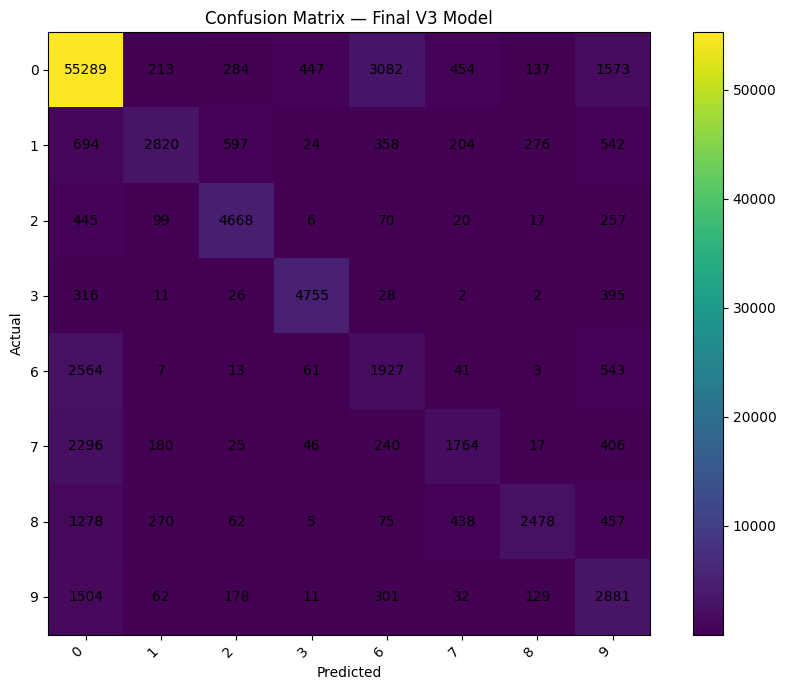

Final metrics and confusion matrix complete.


In [19]:
# Cell 19 — Required metrics, classification report, confusion matrix

import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
)


pred_file = (
    OUTPUT_FOLDER
    / "v2_final_test_predictions.npz"
)


pred_data = np.load(
    pred_file
)


y_true = pred_data["y_true"]
y_pred = pred_data["y_pred"]
y_score = pred_data["y_score"]


class_names = [
    str(x)
    for x in prep["le"].classes_
]


# ------------------------------------------------------------
# Overall metrics
# ------------------------------------------------------------

final_metrics_df = pd.DataFrame(
    [
        {
            "Accuracy":
                accuracy_score(
                    y_true,
                    y_pred,
                ),

            "Balanced Accuracy":
                balanced_accuracy_score(
                    y_true,
                    y_pred,
                ),

            "Macro Precision":
                precision_score(
                    y_true,
                    y_pred,
                    average="macro",
                    zero_division=0,
                ),

            "Macro Recall":
                recall_score(
                    y_true,
                    y_pred,
                    average="macro",
                    zero_division=0,
                ),

            "Macro-F1":
                f1_score(
                    y_true,
                    y_pred,
                    average="macro",
                    zero_division=0,
                ),

            "Weighted Precision":
                precision_score(
                    y_true,
                    y_pred,
                    average="weighted",
                    zero_division=0,
                ),

            "Weighted Recall":
                recall_score(
                    y_true,
                    y_pred,
                    average="weighted",
                    zero_division=0,
                ),

            "Weighted-F1":
                f1_score(
                    y_true,
                    y_pred,
                    average="weighted",
                    zero_division=0,
                ),

            "MCC":
                matthews_corrcoef(
                    y_true,
                    y_pred,
                ),
        }
    ]
)


display(
    final_metrics_df
)


final_metrics_df.to_csv(
    OUTPUT_FOLDER
    / "v2_final_test_metrics.csv",
    index=False,
)


# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0,
    output_dict=True,
)


report_df = (
    pd.DataFrame(
        report
    )
    .transpose()
)


display(
    report_df
)


report_df.to_csv(
    OUTPUT_FOLDER
    / "v2_classification_report.csv"
)


# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
)


fig, ax = plt.subplots(
    figsize=(9, 7)
)


image = ax.imshow(
    cm
)


ax.set_xticks(
    np.arange(
        len(class_names)
    )
)

ax.set_yticks(
    np.arange(
        len(class_names)
    )
)


ax.set_xticklabels(
    class_names,
    rotation=45,
    ha="right",
)

ax.set_yticklabels(
    class_names
)


for i in range(
    cm.shape[0]
):

    for j in range(
        cm.shape[1]
    ):

        ax.text(
            j,
            i,
            int(
                cm[i, j]
            ),
            ha="center",
            va="center",
        )


ax.set_title(
    "Confusion Matrix — Final V3 Model"
)

ax.set_xlabel(
    "Predicted"
)

ax.set_ylabel(
    "Actual"
)


plt.colorbar(
    image,
    ax=ax,
)


plt.tight_layout()


plt.savefig(
    OUTPUT_FOLDER
    / "v2_final_confusion_matrix.png",

    dpi=300,
    bbox_inches="tight",
)


plt.show()


print(
    "Final metrics and confusion matrix complete."
)

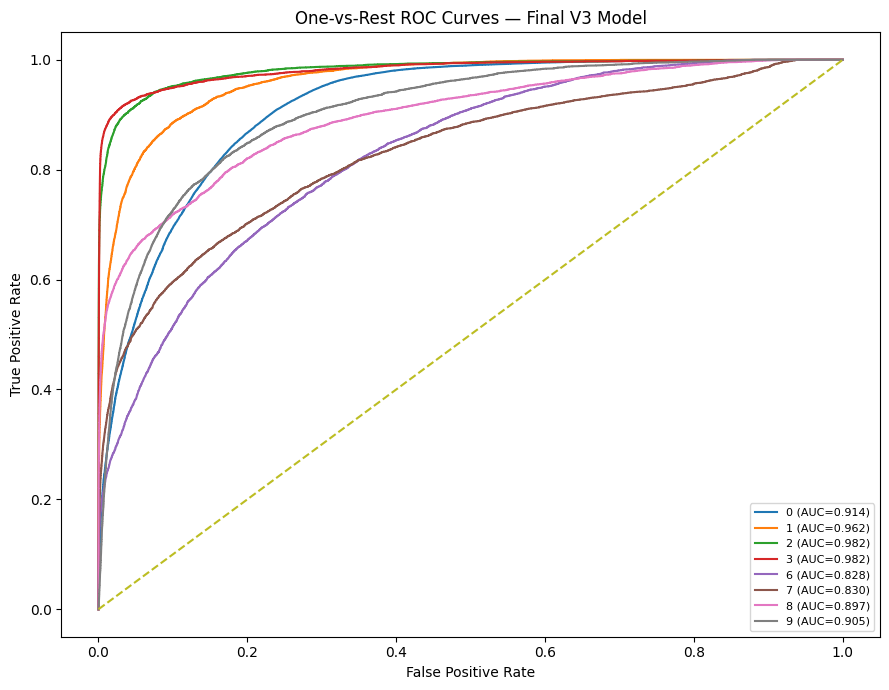

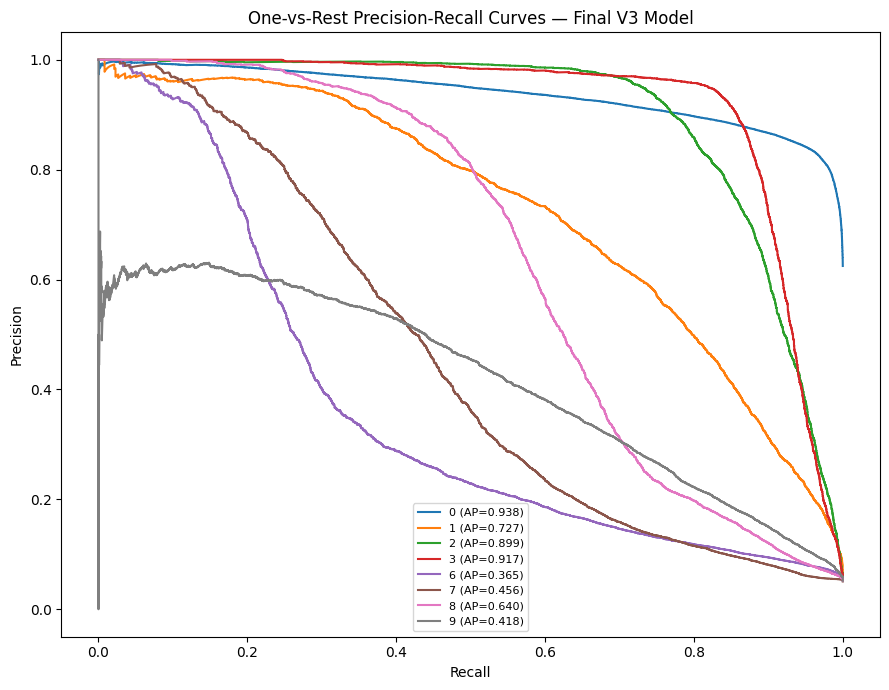

,Macro ROC-AUC,Macro PR-AUC
0,0.912586,0.670023


ROC and Precision-Recall evaluation complete.


In [20]:
# Cell 20 — Required ROC and Precision-Recall curves

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)

from sklearn.preprocessing import (
    label_binarize
)


pred_data = np.load(
    OUTPUT_FOLDER
    / "v2_final_test_predictions.npz"
)


y_true = pred_data["y_true"]
y_score = pred_data["y_score"]


n_classes = y_score.shape[1]


y_binary = label_binarize(
    y_true,
    classes=np.arange(
        n_classes
    ),
)


# ============================================================
# ROC-AUC
# ============================================================

roc_auc_macro = roc_auc_score(
    y_binary,
    y_score,
    average="macro",
    multi_class="ovr",
)


fig, ax = plt.subplots(
    figsize=(9, 7)
)


for i in range(
    n_classes
):

    fpr, tpr, _ = roc_curve(
        y_binary[:, i],
        y_score[:, i],
    )


    auc_i = roc_auc_score(
        y_binary[:, i],
        y_score[:, i],
    )


    ax.plot(
        fpr,
        tpr,
        label=(
            f"{class_names[i]} "
            f"(AUC={auc_i:.3f})"
        ),
    )


ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
)


ax.set_title(
    "One-vs-Rest ROC Curves — Final V3 Model"
)

ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate"
)

ax.legend(
    fontsize=8
)


plt.tight_layout()


plt.savefig(
    OUTPUT_FOLDER
    / "v2_final_roc_curves.png",

    dpi=300,
    bbox_inches="tight",
)


plt.show()


# ============================================================
# Precision–Recall
# ============================================================

pr_auc_macro = average_precision_score(
    y_binary,
    y_score,
    average="macro",
)


fig, ax = plt.subplots(
    figsize=(9, 7)
)


for i in range(
    n_classes
):

    precision_curve, recall_curve, _ = (
        precision_recall_curve(
            y_binary[:, i],
            y_score[:, i],
        )
    )


    ap_i = average_precision_score(
        y_binary[:, i],
        y_score[:, i],
    )


    ax.plot(
        recall_curve,
        precision_curve,
        label=(
            f"{class_names[i]} "
            f"(AP={ap_i:.3f})"
        ),
    )


ax.set_title(
    "One-vs-Rest Precision-Recall Curves — Final V3 Model"
)

ax.set_xlabel(
    "Recall"
)

ax.set_ylabel(
    "Precision"
)

ax.legend(
    fontsize=8
)


plt.tight_layout()


plt.savefig(
    OUTPUT_FOLDER
    / "v2_final_precision_recall_curves.png",

    dpi=300,
    bbox_inches="tight",
)


plt.show()


auc_summary_df = pd.DataFrame(
    [
        {
            "Macro ROC-AUC":
                roc_auc_macro,

            "Macro PR-AUC":
                pr_auc_macro,
        }
    ]
)


display(
    auc_summary_df
)


auc_summary_df.to_csv(
    OUTPUT_FOLDER
    / "v2_final_auc_metrics.csv",
    index=False,
)


print(
    "ROC and Precision-Recall evaluation complete."
)